### Group Members

- **Timo Philipse**  
- **Victor Carmona**  
- **Ioannis Chatzikos**  
- **Kristjana Prifti**  
- **Alvaro Buendia**

---

**Course:** M2 – Natural Language Processing  
**Assignment:** Final NLP Project   
**Date:** 14/10/2025

In [1]:
import os
import json
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import seaborn as sns

#LLM
from openai import OpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field, ValidationError
from typing import List, Optional, Dict
from datetime import date
import time


# network analysis
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

# HuggingFace datasets
from datasets import load_dataset

In [2]:
# Load in dataset
debates = load_dataset("RJuro/eu_debates", split="train")

In [ ]:
# Take only spanish speakers
subset = debates.filter(lambda x: x.get("intervention_language", None) == 'es')

In [4]:
# Only take recent years/corona years
TARGET_YEARS = {"2020","2021","2022"}
ds_es = subset.filter(lambda x: x["year"] in TARGET_YEARS)
# Remove people not from parties
ds_es2 = ds_es.filter(lambda x: x.get("speaker_party") not in [None, "N/A"])

In [5]:
# Only take 1000 speeches to make LLM extraction quicker
ds_es_sample = ds_es2.shuffle(seed=42).select(range(1000)) 

In [6]:
# Make it a panda dataframe
df = ds_es_sample.to_pandas()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   speaker_name           1000 non-null   object        
 1   speaker_role           1000 non-null   object        
 2   speaker_party          1000 non-null   object        
 3   intervention_language  1000 non-null   object        
 4   original_language      1000 non-null   object        
 5   date                   1000 non-null   datetime64[ms]
 6   year                   1000 non-null   object        
 7   debate_title           1000 non-null   object        
 8   text                   1000 non-null   object        
 9   translated_text        1000 non-null   object        
dtypes: datetime64[ms](1), object(9)
memory usage: 78.3+ KB


In [8]:
# Show the distribution of speeches per year
df["year"] = df["date"].dt.year
print(df["year"].value_counts().sort_index())


year
2020    259
2021    354
2022    387
Name: count, dtype: int64


In [9]:
# Different parties and their speeches
party_counts = df['speaker_party'].value_counts()
print(party_counts)

speaker_party
S&D           471
PPE           153
ALDE          113
GUE/NGL       107
ECR            83
Greens/EFA     58
NI             15
Name: count, dtype: int64


# **Model**

In [ ]:
# Load environment variables from .env file

load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")

client = None
if not api_key:
    print("⚠️ Set GEMINI_API_KEY in environment or a .env file")
else:
    # Configure the OpenAI client to point to Google's endpoint
    client = OpenAI(
        api_key=api_key,
        base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
    )
    print("✅ OpenAI client configured for Gemini.")

✅ OpenAI client configured for Gemini.


In [ ]:
# Final model we used

#  Define schema 

class DebateExtraction(BaseModel):
    """Schema for extracting the main topic from a speech."""
    topic: str = Field(description="The main policy issue discussed in the speech.")

debate_schema = DebateExtraction.model_json_schema()


# Extraction function

def extract_topic(text, retries=2):
    """
    Extract the main topic from one speech using Gemini-lite.
    Returns a DebateExtraction object or None if extraction fails.
    Ensures the topic is 1 to 5 words, lowercase, no punctuation.

    """
    for attempt in range(retries):
        try:
            completion = client.chat.completions.create(
                model="gemini-2.5-flash-lite",
                messages=[
                    {
                        "role": "system",
                        "content": "Extract the main topic of this European Parliament speech."
                                   "Return your answer as a JSON object with the key 'topic'. Do not invent facts not present in the text."
                                    "The topic must be 1 to 5 words, all lowercase, no punctuation."
                          
                    },
                    {"role": "user", "content": text}
                ],
                response_format={
                    "type": "json_schema",
                    "json_schema": {"name": "DebateExtraction", "strict": True, "schema": debate_schema}
                },
                timeout=60
            )

            choice = completion.choices[0]
            response_text = getattr(getattr(choice, "message", None), "content",
                                    getattr(choice, "text", None)) or getattr(completion, "text", None)

            # Validate & parse JSON
            extracted = DebateExtraction.model_validate_json(response_text)
            return extracted

        except ValidationError as ve:
            print(f"Validation error on attempt {attempt+1}: {ve}")
            time.sleep(1)
        except Exception as e:
            print(f"Error on attempt {attempt+1}: {e}")
            time.sleep(1)
    return None


# Loop over all speeches

extracted_list = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    speech_text = row['translated_text']
    result = extract_topic(speech_text)

    if result is not None:
        # Use the other data from already existing columns
        extracted_list.append({
            "speaker": row['speaker_name'],
            "party": row['speaker_party'],
            "topic": result.topic,
            "year": row['year']  
        })
    else:
        print(f"Skipping row {idx} due to extraction failure.")


# Convert to DataFrame

extracted_df = pd.DataFrame(extracted_list)
print(f"Successfully extracted {len(extracted_df)} out of {len(df)} speeches.")

# Save to CSV
extracted_df.to_csv("extracted_debate_topicsyears.csv", index=False)
print("✅ Extraction saved to extracted_debate_topicsyears.csv")


100%|██████████| 1000/1000 [09:13<00:00,  1.81it/s]

Successfully extracted 1000 out of 1000 speeches.
✅ Extraction saved to extracted_debate_topicsyears.csv


# Loading in the dataset

In [3]:
#Load in the generated topic data
df_topic=pd.read_csv("extracted_debate_topicsyears.csv")

# **Descriptive exploration**

In [4]:
#Check the topics with the exact same wording
df_topic['topic'].value_counts().head(10)

topic
rule of law                          9
gender violence                      8
multiannual financial framework      6
energy prices and inflation          5
water scarcity and climate change    5
reproductive rights                  5
digital services act                 5
rule of law conditionality           5
european recovery plan               4
abortion rights                      4
Name: count, dtype: int64

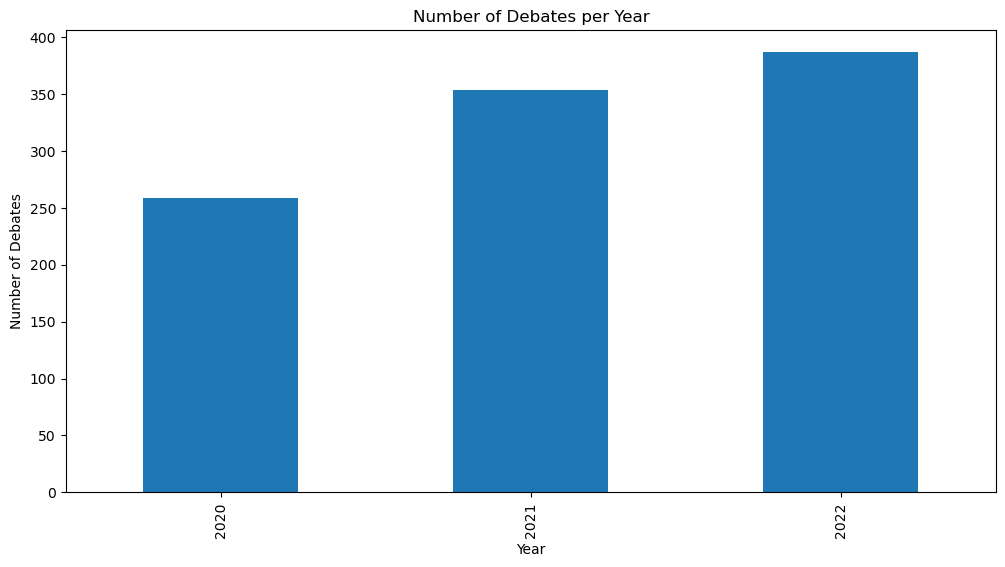

In [13]:
# Show distribution of debates over the years
year_counts = df_topic['year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
year_counts.plot(kind='bar')
plt.title('Number of Debates per Year')
plt.xlabel('Year')
plt.ylabel('Number of Debates')
plt.show()

In [5]:
# Speakers with the most amount of debates
df_topic['speaker'].value_counts().head(5)

speaker
Juan Fernando López Aguilar    56
Iratxe García Pérez            44
Domènec Ruiz Devesa            37
Hermann Tertsch                31
Javi López                     29
Name: count, dtype: int64

C:\Users\timo\AppData\Local\Temp\ipykernel_7712\1260202124.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_counts, x='party', y='num_debates', palette='viridis')


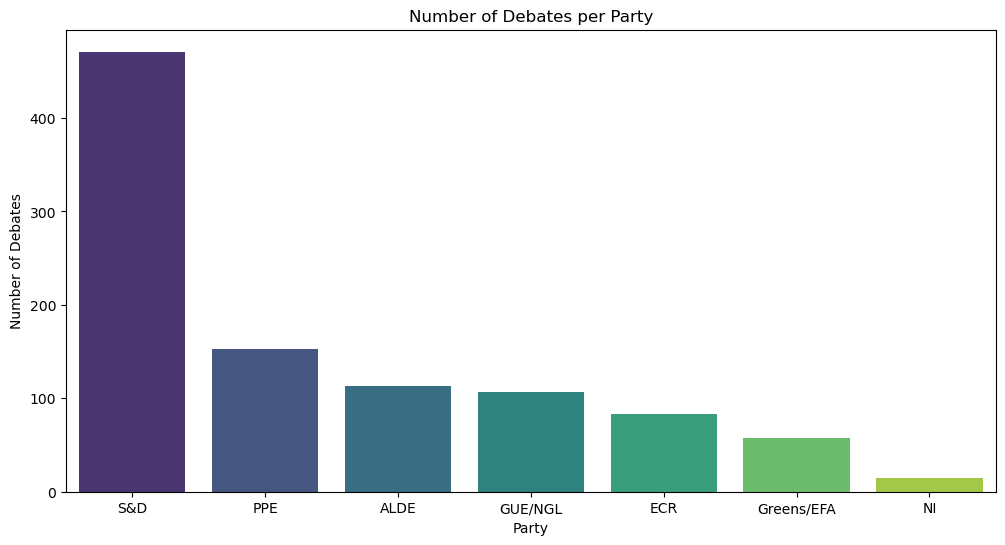

In [12]:
# Show which party had the most speeches
party_counts = df_topic.groupby('party').size().reset_index(name='num_debates')
party_counts = party_counts.sort_values(by='num_debates', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=party_counts, x='party', y='num_debates', palette='viridis')
plt.title("Number of Debates per Party")
plt.xlabel("Party")
plt.ylabel("Number of Debates")
plt.show()

**Assess LLM extraction quality**

In [16]:
#Put the generated topics together with the original speeches
merged_df = df.copy()
merged_df['topic'] = df_topic['topic']

# Take a random sample of 5 
sample_df = merged_df.sample(5, random_state=42)

# Show comparison of both
for idx, row in sample_df.iterrows():
    print(f"Speaker: {row['speaker_name']} ({row['speaker_party']}, {row['year']})")
    print(f"Assigned Topic: {row['topic']}")
    print("\nOriginal Text:\n")
    print(row['translated_text']) 


Speaker: Isabel Benjumea Benjumea (PPE, 2022)
Assigned Topic: inflation and recovery funds

Original Text:

on behalf of the PPE Group. – Mr. President, Mr. Commissioner, Mr. Minister, in the face of the growing inflation – I would say a striking inflation – that we are living in Europe, which overwhelmingly punishes the families, the self-employed, the SMEs and anyone who is trying to develop an economic activity, but also anyone who is trying to get to the end of the month – and many are increasingly expensive – Europe has put above the table, following the COVID crisis –19, a stimulation plan that implies an injection of unprecedented European funds, which are the funds of NextGenerationEU. As our Commissioner just said, he has now also put the REPowerEU Plan above the table. Therefore, Europe has demonstrated that solidarity and now it is time to know how to take advantage of these funds very well, so that they serve to face this challenge of lowering inflation and helping families

**Main Limitation/systematic errors:**
- Same topics don't always have the same wording for topics, so basically being incosistent
- Speeches could have multiple topics in them, but we only report one for example
- To make the topic easier to understand we only have max 5 words, which could make the topics unclear and overgeneralized
- Because we only use translated text, it could be different topic than the actual Spanish speech


Strength of using LLM
- Handles natural language naturally
- Flexible, can change prompt easily


# **Knowledge graph/network**

In [4]:
df_net = df_topic.copy()

# Find the 10 most common topics
top_topics = df_net['topic'].value_counts().head(10).index.tolist()

df_net = df_net[df_net['topic'].isin(top_topics)]


In [ ]:
G = nx.Graph()

# Add nodes for speakers and topics
speakers = df_net['speaker'].unique()
topics = df_net['topic'].unique()

G.add_nodes_from(speakers, bipartite='speakers')
G.add_nodes_from(topics, bipartite='topics')

# Add edges 
for _, row in df_net.iterrows():
    G.add_edge(row['speaker'], row['topic'])


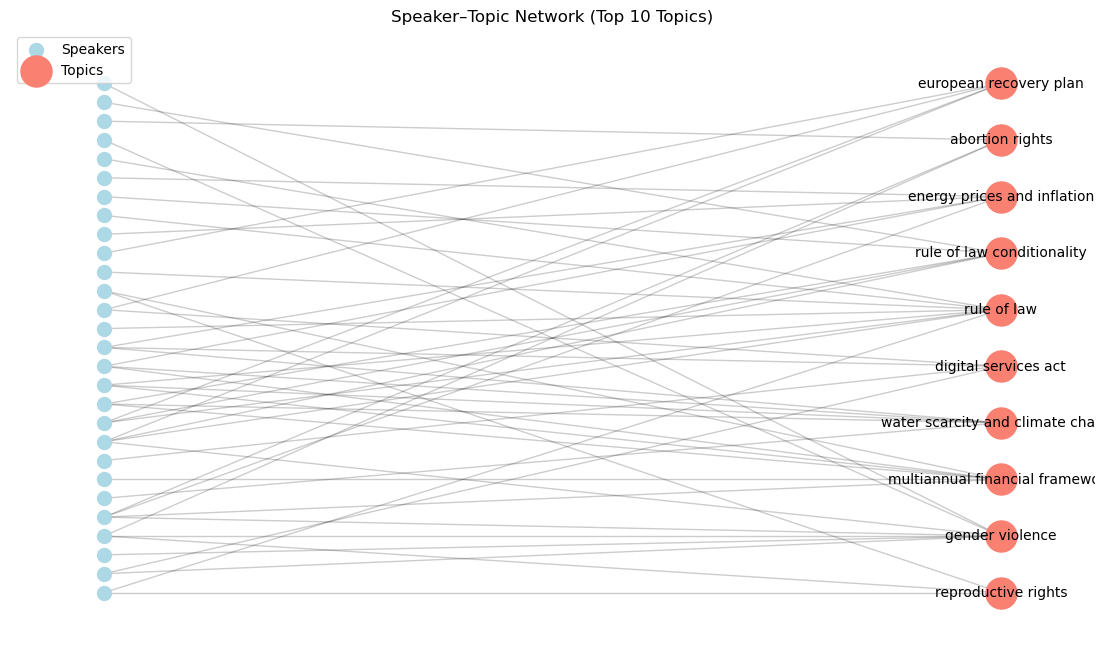

In [6]:
# Separate the node sets
speaker_nodes = [n for n, d in G.nodes(data=True) if d['bipartite'] == 'speakers']
topic_nodes = [n for n, d in G.nodes(data=True) if d['bipartite'] == 'topics']

# Position nodes
pos = nx.bipartite_layout(G, speaker_nodes)

plt.figure(figsize=(14, 8))

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.2)

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=speaker_nodes, node_color='lightblue', node_size=100, label='Speakers')
nx.draw_networkx_nodes(G, pos, nodelist=topic_nodes, node_color='salmon', node_size=500, label='Topics')

# Draw labels 
nx.draw_networkx_labels(G, pos, labels={t: t for t in topic_nodes}, font_size=10)

plt.title("Speaker–Topic Network (Top 10 Topics)")
plt.axis('off')
plt.legend()
plt.show()


In [7]:

# Compute betweenness centrality for speakers
centrality = bipartite.betweenness_centrality(
    G,
    nodes=[n for n, d in G.nodes(data=True) if d.get('bipartite') == 'speakers']  
)

# Separate results for speakers and topics
speaker_centrality = {node: score for node, score in centrality.items() if node in speakers}
topic_centrality = {node: score for node, score in centrality.items() if node in topics}


# Display top connectors

print("\nTop 5 Most Central Speakers (connect many diverse topics):")
print(pd.Series(speaker_centrality).sort_values(ascending=False).head(5))

print("\nTop 5 Most Central Topics (bridge between many different speakers):")
print(pd.Series(topic_centrality).sort_values(ascending=False).head(5))



Top 5 Most Central Speakers (connect many diverse topics):
Iratxe García Pérez       0.247367
César Luena               0.208381
Ibán García Del Blanco    0.133600
Clara Aguilera            0.095730
Isabel García Muñoz       0.090057
dtype: float64

Top 5 Most Central Topics (bridge between many different speakers):
gender violence                    0.312352
rule of law                        0.291120
multiannual financial framework    0.192095
rule of law conditionality         0.147917
energy prices and inflation        0.145738
dtype: float64


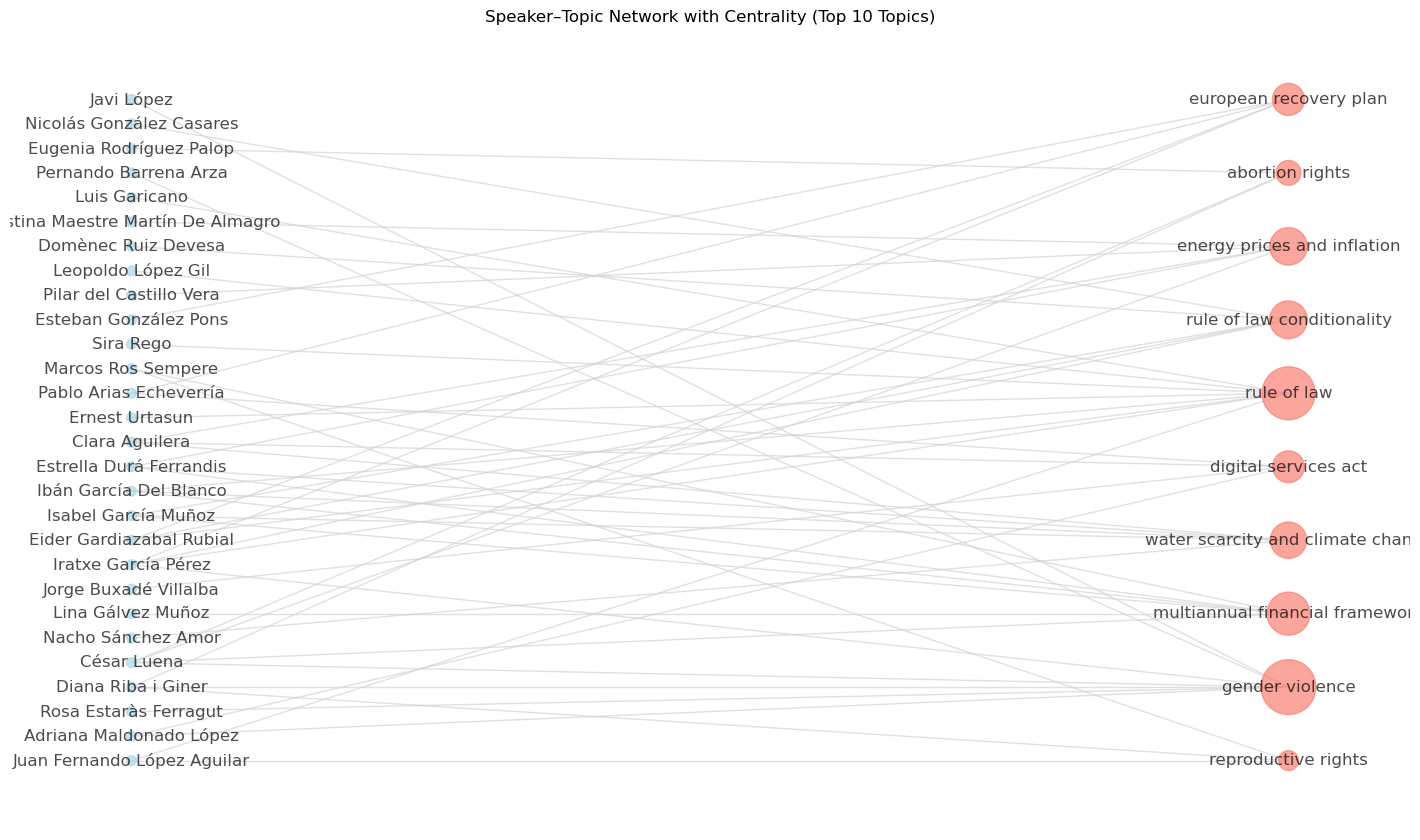

In [8]:
# Add the names of the speaker and have the size for how central they are

pos = nx.bipartite_layout(G, speakers)
sizes = [5000 * topic_centrality.get(n, 0.01) for n in G.nodes()] 

plt.figure(figsize=(14, 8))
nx.draw(G, pos,
        with_labels=True,
        node_color=['salmon' if n in topics else 'lightblue' for n in G.nodes()],
        node_size=sizes,
        edge_color='lightgray',
        alpha=0.7)
plt.title("Speaker–Topic Network with Centrality (Top 10 Topics)")
plt.axis('off')
plt.show()


In [9]:

# Degree centrality
degree_centrality = bipartite.degree_centrality(G, speaker_nodes)

# Betweenness centrality
betweenness_centrality = bipartite.betweenness_centrality(G, nodes=speaker_nodes)

# Closeness centrality
closeness_centrality = bipartite.closeness_centrality(G, nodes=speaker_nodes)



# Speakers
df_speakers = pd.DataFrame({
    'speaker': speaker_nodes,
    'degree': [degree_centrality[s] for s in speaker_nodes],
    'betweenness': [betweenness_centrality[s] for s in speaker_nodes],
    'closeness': [closeness_centrality[s] for s in speaker_nodes],
})

# Topics
df_topics = pd.DataFrame({
    'topic': topic_nodes,
    'degree': [bipartite.degree_centrality(G, topic_nodes)[t] for t in topic_nodes],
    'betweenness': [bipartite.betweenness_centrality(G, nodes=topic_nodes)[t] for t in topic_nodes],
    'closeness': [bipartite.closeness_centrality(G, nodes=topic_nodes)[t] for t in topic_nodes]
})

# View top nodes by measure
print("Top 5 Speakers by Degree:")
print(df_speakers.sort_values('degree', ascending=False).head())

print("\nTop 5 Topics by Degree:")
print(df_topics.sort_values('degree', ascending=False).head())


Top 5 Speakers by Degree:
                     speaker  degree  betweenness  closeness
8        Iratxe García Pérez     0.4     0.247367   0.680851
4                César Luena     0.4     0.208381   0.640000
3         Diana Riba i Giner     0.3     0.068739   0.542373
9   Eider Gardiazabal Rubial     0.3     0.062786   0.542373
11    Ibán García Del Blanco     0.3     0.133600   0.615385

Top 5 Topics by Degree:
                               topic    degree  betweenness  closeness
5                        rule of law  0.285714     0.291120   0.460000
1                    gender violence  0.250000     0.312352   0.500000
2    multiannual financial framework  0.214286     0.192095   0.460000
7        energy prices and inflation  0.178571     0.145738   0.389831
3  water scarcity and climate change  0.178571     0.136779   0.410714


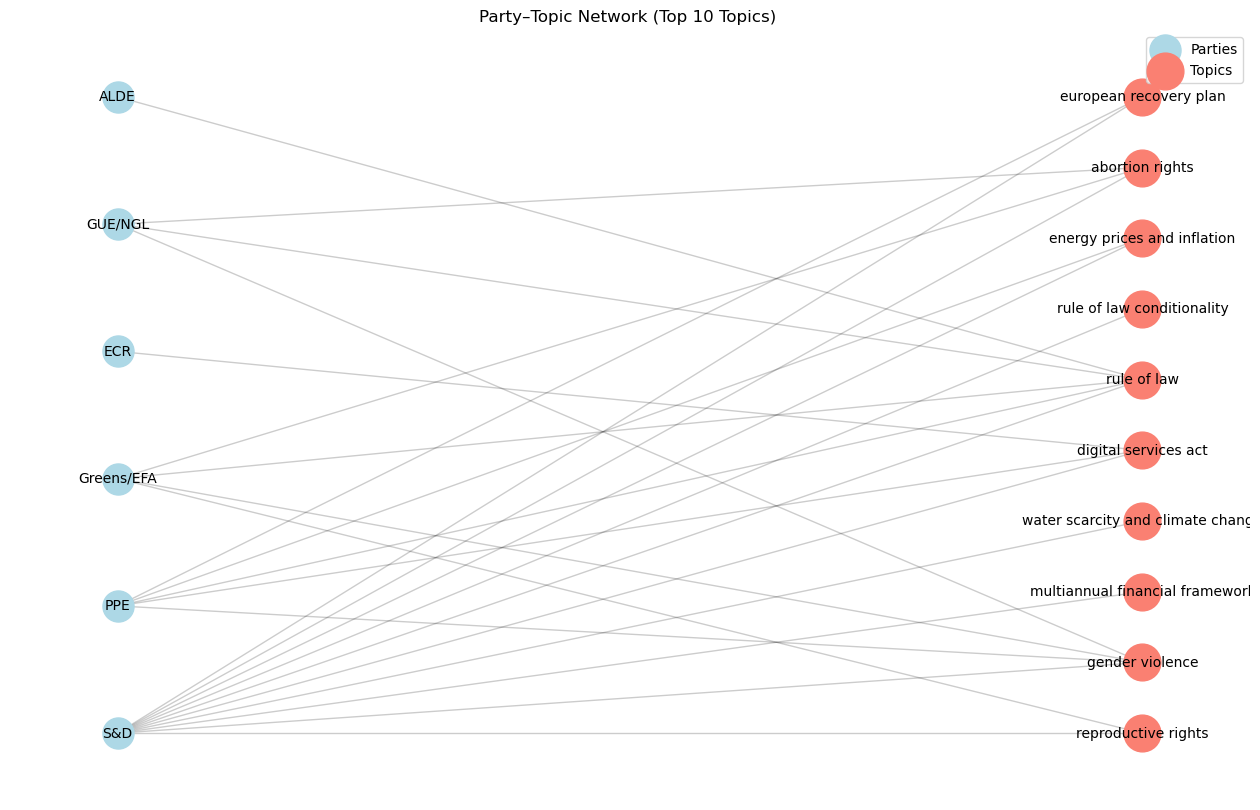

In [ ]:
G = nx.Graph()

# Add nodes for parties and topics
parties = df_net['party'].unique()
topics = df_net['topic'].unique()

G.add_nodes_from(parties, bipartite='parties')
G.add_nodes_from(topics, bipartite='topics')

for _, row in df_net.iterrows():
    G.add_edge(row['party'], row['topic'])

# Separate the node sets
party_nodes = [n for n, d in G.nodes(data=True) if d['bipartite'] == 'parties']
topic_nodes = [n for n, d in G.nodes(data=True) if d['bipartite'] == 'topics']

# Position nodes
pos = nx.bipartite_layout(G, party_nodes)

plt.figure(figsize=(16, 10))

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.2)

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=party_nodes, node_color='lightblue', node_size=500, label='Parties')
nx.draw_networkx_nodes(G, pos, nodelist=topic_nodes, node_color='salmon', node_size=700, label='Topics')

# Draw labels for both parties and topics
labels = {n: n for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)

plt.title("Party–Topic Network (Top 10 Topics) ")
plt.axis('off')
plt.legend()
plt.show()



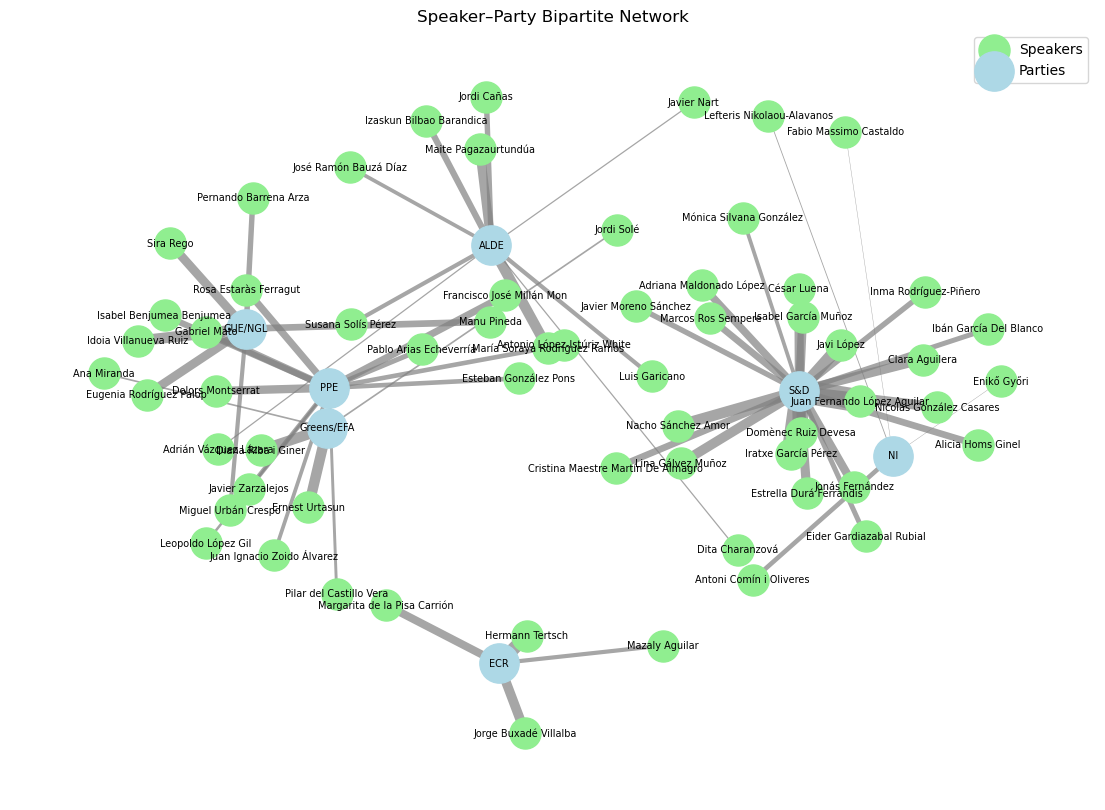

In [ ]:
B = nx.Graph()

# Add the party and speaker nodes
speakers = df_topic['speaker'].unique()
parties = df_topic['party'].unique()

B.add_nodes_from(speakers, bipartite='speakers', color='lightgreen')
B.add_nodes_from(parties, bipartite='parties', color='lightblue')

# Add weighted edges: speaker–party
for _, row in df_topic.iterrows():
    speaker = row['speaker']
    party = row['party']
    if B.has_edge(speaker, party):
        B[speaker][party]['weight'] += 1
    else:
        B.add_edge(speaker, party, weight=1)

# Visualize bipartite graph

plt.figure(figsize=(14,10))

# Separate node sets
speaker_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'speakers']
party_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'parties']

pos = nx.spring_layout(B, k=1, seed=42)

# Draw nodes
nx.draw_networkx_nodes(B, pos, nodelist=speaker_nodes, node_color='lightgreen', node_size=500, label='Speakers')
nx.draw_networkx_nodes(B, pos, nodelist=party_nodes, node_color='lightblue', node_size=800, label='Parties')

# Draw edges with weight to the number of debates
edges = B.edges()
weights = [B[u][v]['weight'] for u, v in edges]
nx.draw_networkx_edges(B, pos, edgelist=edges, width=[w*0.3 for w in weights], alpha=0.7, edge_color='gray')

# Draw labels
nx.draw_networkx_labels(B, pos, font_size=7)

plt.title("Speaker–Party Bipartite Network")
plt.legend(scatterpoints=1)
plt.axis('off')
plt.show()
